# EDA - E-commerce Fraud Data

Univariate & bivariate exploration of `Fraud_Data.csv`, plus the class-imbalance picture. Data cleaning logic lives in `src.cleaning`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
from src import config, data_loading, cleaning
raw = data_loading.load_fraud_data()
print('raw shape:', raw.shape)
raw.head()

raw shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## Schema & data types

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 16.0 MB


## Missing values & duplicates

In [4]:
display(cleaning.missing_value_report(raw))
print('exact duplicate rows:', raw.duplicated().sum())

,missing_count,missing_pct,dtype
user_id,0,0.0,int64
signup_time,0,0.0,datetime64[us]
purchase_time,0,0.0,datetime64[us]
purchase_value,0,0.0,int64
device_id,0,0.0,str
source,0,0.0,str
browser,0,0.0,str
sex,0,0.0,str
age,0,0.0,int64
ip_address,0,0.0,float64


exact duplicate rows: 0


In [5]:
df = cleaning.clean_fraud_data(raw)
print('after cleaning:', df.shape)

after cleaning: (151112, 11)


## Class imbalance
The positive (fraud) class is a small minority - this drives our metric and resampling choices.

,count,pct
class,,
0,136961,90.6354
1,14151,9.3646


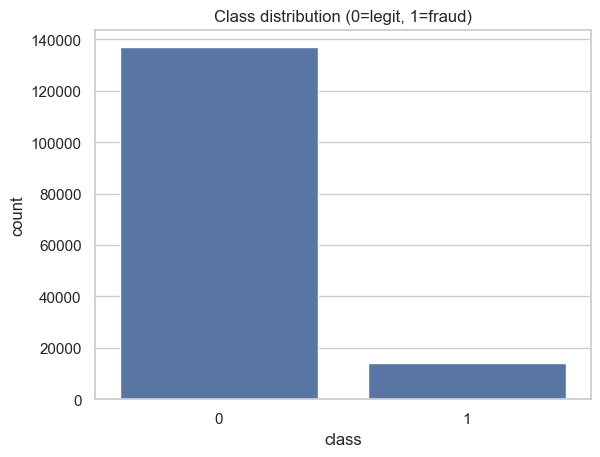

In [6]:
bal = cleaning.class_balance(df, config.FRAUD_TARGET)
display(bal)
ax = sns.countplot(x=config.FRAUD_TARGET, data=df)
ax.set_title('Class distribution (0=legit, 1=fraud)')
plt.savefig(config.FIGURES_DIR/'fraud_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## Univariate distributions

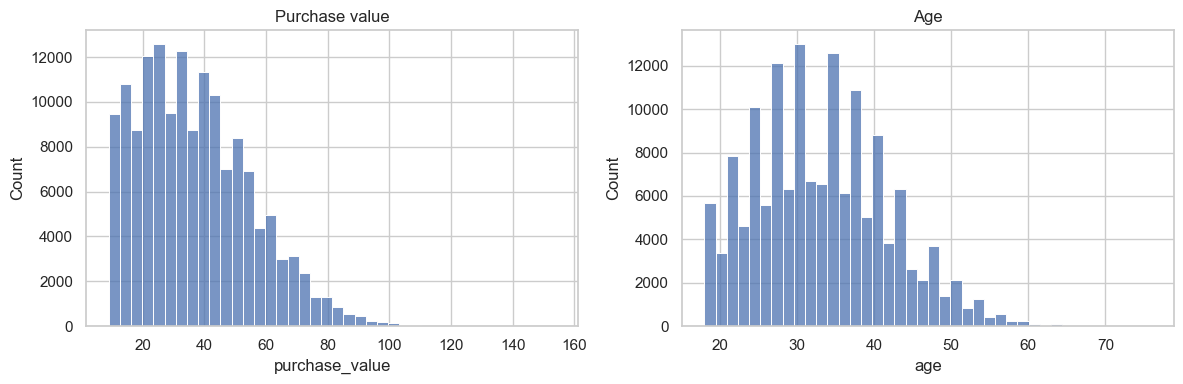

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['purchase_value'], bins=40, ax=axes[0]).set_title('Purchase value')
sns.histplot(df['age'], bins=40, ax=axes[1]).set_title('Age')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fraud_univariate.png', dpi=120, bbox_inches='tight'); plt.show()

In [8]:
for col in ['source', 'browser', 'sex']:
    print(col); print(df[col].value_counts(normalize=True).round(3)); print()

source
source
SEO       0.401
Ads       0.396
Direct    0.203
Name: proportion, dtype: float64

browser
browser
Chrome     0.407
IE         0.243
Safari     0.163
FireFox    0.163
Opera      0.024
Name: proportion, dtype: float64

sex
sex
M    0.584
F    0.416
Name: proportion, dtype: float64



## Bivariate: fraud rate by category
How does the fraud rate vary across channels, browsers and gender?

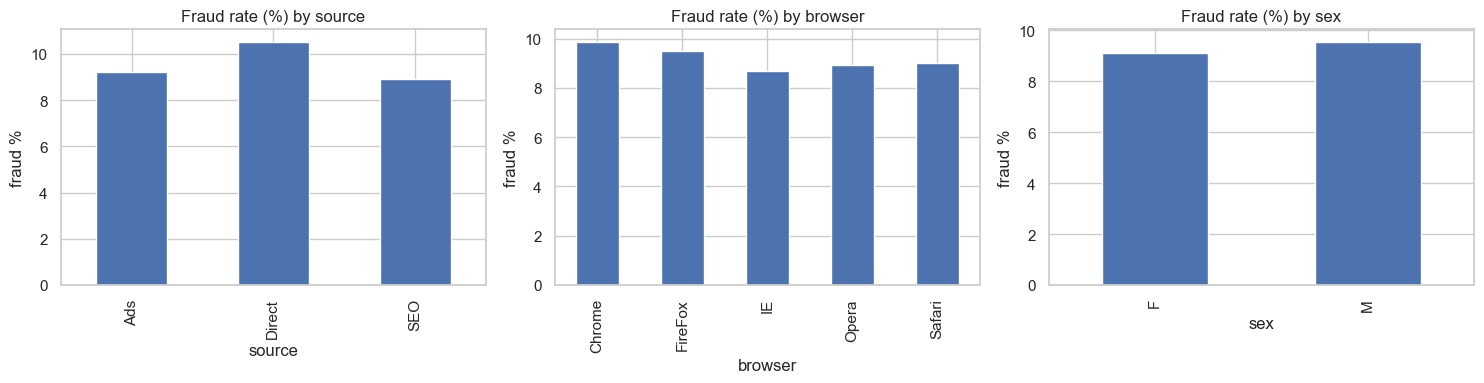

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['source', 'browser', 'sex']):
    (df.groupby(col)[config.FRAUD_TARGET].mean()*100).plot.bar(ax=ax)
    ax.set_title(f'Fraud rate (%) by {col}'); ax.set_ylabel('fraud %')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR/'fraud_rate_by_category.png', dpi=120, bbox_inches='tight'); plt.show()

## Bivariate: purchase value vs class

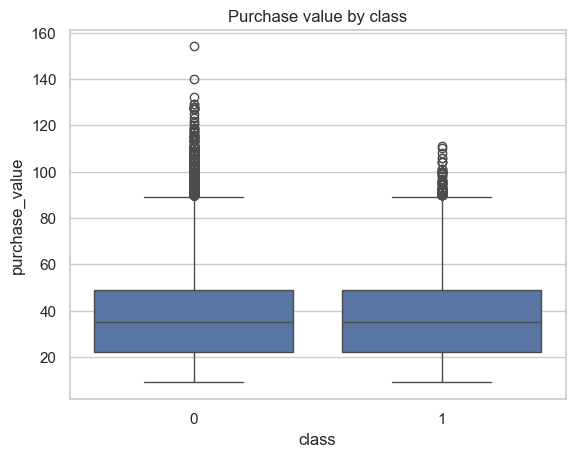

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,136961.0,36.929418,18.315064,9.0,22.0,35.0,49.0,154.0
1,14151.0,36.993004,18.397654,9.0,22.0,35.0,49.0,111.0


In [10]:
ax = sns.boxplot(x=config.FRAUD_TARGET, y='purchase_value', data=df)
ax.set_title('Purchase value by class'); plt.show()
df.groupby(config.FRAUD_TARGET)['purchase_value'].describe()

### Takeaways
- Fraud is a small minority -> use **AUC-PR / F1**, not accuracy.
- Fraud rate differs by `source`/`browser` -> these are useful categorical signals.
- Temporal & velocity features (built in the feature-engineering notebook) are expected to be the strongest predictors.